<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

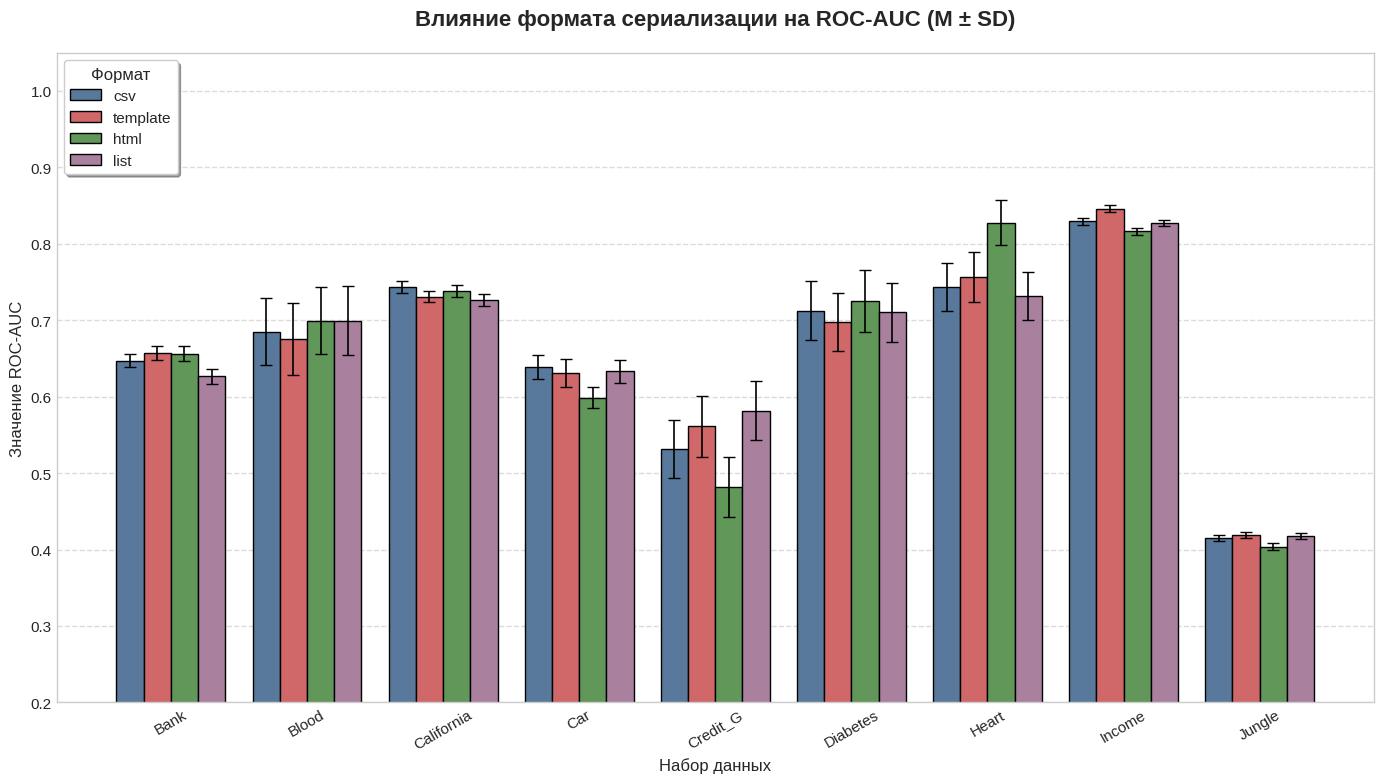

In [ ]:
import pandas as pd
import io
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.container import BarContainer

csv_data = """Dataset,Format,ROC-AUC,F1_Macro,Accuracy,Precision,Recall,Time_sec
Bank,csv,0.6468±0.0085,0.4794±0.0052,0.5637±0.0051,0.5489±0.0034,0.6180±0.0076,807.9
Bank,template,0.6570±0.0088,0.4944±0.0052,0.5905±0.0050,0.5504±0.0035,0.6205±0.0077,1121.3
Bank,html,0.6564±0.0097,0.5032±0.0051,0.6073±0.0048,0.5512±0.0036,0.6209±0.0078,1488.4
Bank,list,0.6265±0.0094,0.4946±0.0052,0.5970±0.0051,0.5464±0.0035,0.6103±0.0079,849.8
Blood,csv,0.6848±0.0439,0.4991±0.0393,0.5068±0.0394,0.5958±0.0312,0.6194±0.0373,10.2
Blood,template,0.6754±0.0476,0.5276±0.0394,0.5407±0.0394,0.6006±0.0309,0.6323±0.0387,12.1
Blood,html,0.6996±0.0439,0.5276±0.0390,0.5408±0.0390,0.6006±0.0305,0.6323±0.0381,13.9
Blood,list,0.6994±0.0449,0.5352±0.0393,0.5472±0.0393,0.6119±0.0306,0.6461±0.0378,11.1
California,csv,0.7439±0.0077,0.6777±0.0076,0.6777±0.0076,0.6778±0.0076,0.6777±0.0076,417.3
California,template,0.7311±0.0078,0.6626±0.0076,0.6639±0.0076,0.6665±0.0077,0.6640±0.0076,373.4
California,html,0.7389±0.0078,0.6678±0.0077,0.6678±0.0077,0.6678±0.0077,0.6678±0.0077,506.1
California,list,0.7270±0.0079,0.6644±0.0077,0.6645±0.0077,0.6645±0.0077,0.6645±0.0077,357.0
Car,csv,0.6384±0.0157,0.1905±0.0232,0.2721±0.0242,0.2120±0.0209,0.2613±0.0372,24.7
Car,template,0.6314±0.0185,0.1996±0.0252,0.2753±0.0244,0.2073±0.0220,0.2570±0.0377,28.9
Car,html,0.5987±0.0140,0.1658±0.0241,0.2171±0.0220,0.1843±0.0244,0.2612±0.0363,36.6
Car,list,0.6334±0.0151,0.2091±0.0264,0.2745±0.0244,0.2273±0.0250,0.3026±0.0378,25.3
Credit_G,csv,0.5317±0.0383,0.4849±0.0342,0.4863±0.0342,0.5887±0.0303,0.5858±0.0294,24.6
Credit_G,template,0.5612±0.0395,0.4899±0.0348,0.4912±0.0348,0.5786±0.0306,0.5798±0.0312,32.7
Credit_G,html,0.4817±0.0392,0.4388±0.0346,0.4401±0.0346,0.5190±0.0327,0.5192±0.0332,46.4
Credit_G,list,0.5819±0.0389,0.4647±0.0341,0.4664±0.0341,0.5706±0.0315,0.5669±0.0301,28.1
Diabetes,csv,0.7127±0.0391,0.5893±0.0393,0.5931±0.0390,0.6186±0.0360,0.6271±0.0380,14.7
Diabetes,template,0.6982±0.0378,0.5651±0.0397,0.5667±0.0396,0.6181±0.0359,0.6194±0.0363,16.0
Diabetes,html,0.7252±0.0405,0.6229±0.0380,0.6317±0.0374,0.6350±0.0355,0.6481±0.0383,21.0
Diabetes,list,0.7104±0.0384,0.5767±0.0392,0.5793±0.0390,0.6144±0.0356,0.6203±0.0371,15.4
Heart,csv,0.7437±0.0318,0.6698±0.0377,0.7120±0.0335,0.7789±0.0326,0.6819±0.0298,16.6
Heart,template,0.7566±0.0324,0.6917±0.0365,0.7278±0.0327,0.7896±0.0308,0.6996±0.0299,19.1
Heart,html,0.8279±0.0294,0.6703±0.0380,0.7124±0.0336,0.7790±0.0328,0.6824±0.0303,27.3
Heart,list,0.7322±0.0312,0.6589±0.0385,0.7066±0.0341,0.7857±0.0322,0.6746±0.0294,18.1
Income,csv,0.8294±0.0043,0.7048±0.0049,0.7483±0.0044,0.6960±0.0044,0.7530±0.0050,1298.8
Income,template,0.8462±0.0041,0.7338±0.0049,0.7890±0.0041,0.7209±0.0048,0.7577±0.0051,1661.1
Income,html,0.8166±0.0045,0.6805±0.0049,0.7182±0.0045,0.6800±0.0042,0.7405±0.0049,2023.2
Income,list,0.8274±0.0043,0.7120±0.0050,0.7632±0.0043,0.7000±0.0047,0.7465±0.0052,1464.7
Jungle,csv,0.4146±0.0039,0.2032±0.0040,0.2434±0.0047,0.2186±0.0041,0.2000±0.0047,688.2
Jungle,template,0.4192±0.0039,0.2085±0.0042,0.2469±0.0048,0.2239±0.0042,0.2076±0.0049,731.6
Jungle,html,0.4038±0.0045,0.2046±0.0043,0.2213±0.0044,0.2211±0.0044,0.2336±0.0059,884.8
Jungle,list,0.4174±0.0040,0.2093±0.0042,0.2463±0.0047,0.2228±0.0041,0.2109±0.0050,698.9"""

df_results = pd.read_csv(io.StringIO(csv_data))

def parse_metric(val):
    if isinstance(val, str) and "±" in val:
        mean, std = val.split("±")
        return float(mean), float(std)
    elif val == "N/A":
        return 0.0, 0.0
    return float(val), 0.0

df_results["ROC-AUC_mean"], df_results["ROC-AUC_sd"] = zip(*df_results["ROC-AUC"].apply(parse_metric))

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))

formats = ['csv', 'template', 'html', 'list']
dark_palette = {"csv": "#4e79a7", "template": "#e15759", "html": "#59a14f", "list": "#b07aa1"}

# Barplot 생성
sns.barplot(
    data=df_results,
    x='Dataset',
    y='ROC-AUC_mean',
    hue='Format',
    hue_order=formats,
    palette=dark_palette,
    ax=ax,
    edgecolor='black'
)

bar_containers = [c for c in ax.containers if isinstance(c, BarContainer)]
for j, container in enumerate(bar_containers):
    current_format = formats[j]
    yerr = df_results[df_results['Format'] == current_format]['ROC-AUC_sd'].values
    x_pos = [bar.get_x() + bar.get_width() / 2 for bar in container]
    y_pos = [bar.get_height() for bar in container]

    ax.errorbar(x=x_pos, y=y_pos, yerr=yerr, fmt='none', c='black', capsize=4, elinewidth=1.2)

ax.set_title('Влияние формата сериализации на ROC-AUC (M ± SD)', fontsize=16, fontweight='bold', pad=20)

ax.set_ylim(0.2, 1.05)
ax.set_ylabel('Значение ROC-AUC', fontsize=12)
ax.set_xlabel('Набор данных', fontsize=12)

ax.legend(title='Формат', loc='upper left', frameon=True, shadow=True)

ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
file_name = 'serialization_roc_auc_final_style.png'
plt.savefig(file_name, dpi=300, bbox_inches='tight')

try:
    from google.colab import files
    files.download(file_name)
except ImportError:
    pass

plt.show()

/tmp/ipykernel_14651/4057924556.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(dataset_names)).colors


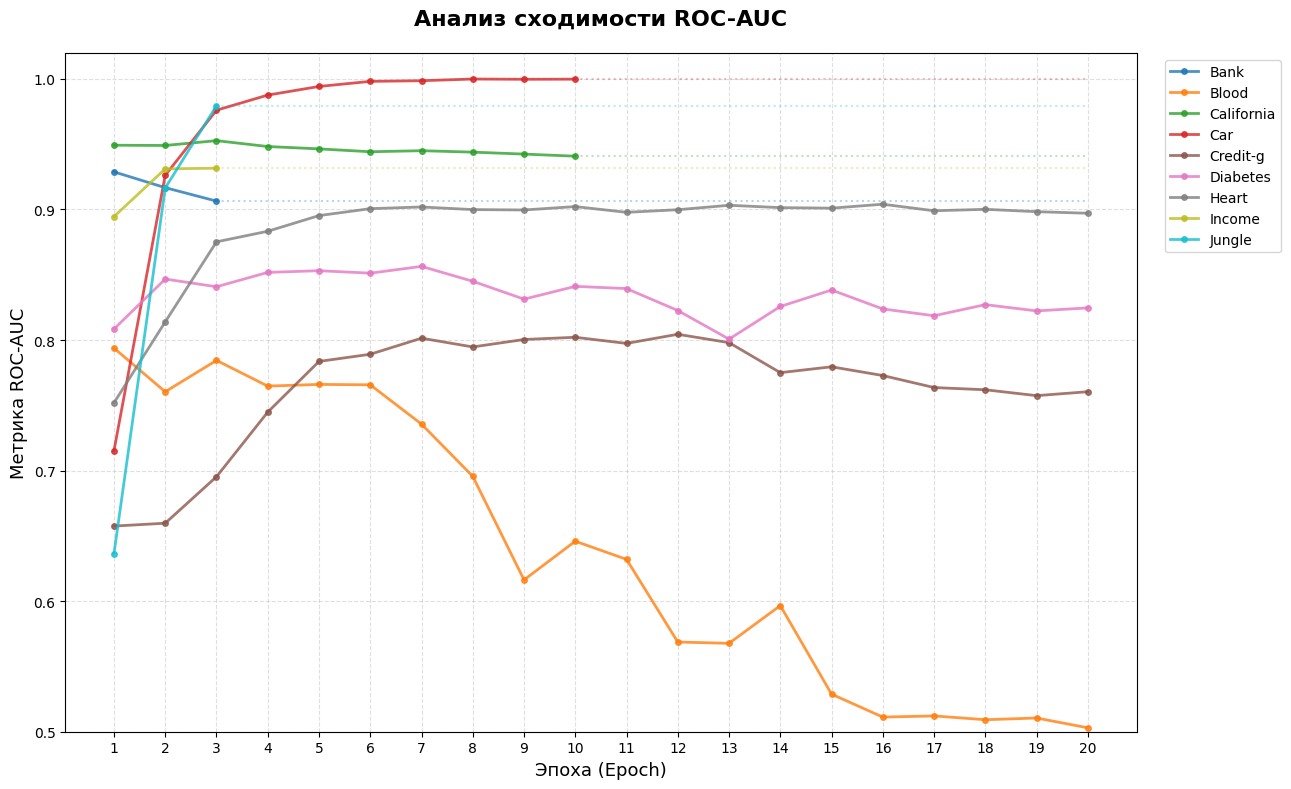

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

epoch_data = {
    "Bank": [0.9288, 0.9167, 0.9064],
    "Blood": [0.7938, 0.7604, 0.7844, 0.7647, 0.7660, 0.7657, 0.7356, 0.6956, 0.6163, 0.6459, 0.6320, 0.5687, 0.5677, 0.5966, 0.5288, 0.5112, 0.5121, 0.5092, 0.5105, 0.5030],
    "California": [0.9492, 0.9490, 0.9527, 0.9482, 0.9464, 0.9442, 0.9450, 0.9439, 0.9424, 0.9408],
    "Car": [0.7152, 0.9262, 0.9760, 0.9876, 0.9942, 0.9981, 0.9986, 0.9999, 0.9997, 0.9998],
    "Credit-g": [0.6575, 0.6597, 0.6953, 0.7448, 0.7836, 0.7891, 0.8014, 0.7947, 0.8004, 0.8021, 0.7974, 0.8044, 0.7980, 0.7750, 0.7795, 0.7728, 0.7636, 0.7619, 0.7574, 0.7604],
    "Diabetes": [0.8084, 0.8467, 0.8408, 0.8518, 0.8531, 0.8512, 0.8564, 0.8450, 0.8313, 0.8411, 0.8394, 0.8226, 0.8007, 0.8257, 0.8383, 0.8238, 0.8186, 0.8271, 0.8223, 0.8246],
    "Heart": [0.7519, 0.8139, 0.8752, 0.8833, 0.8953, 0.9006, 0.9019, 0.8999, 0.8996, 0.9022, 0.8978, 0.8998, 0.9032, 0.9014, 0.9010, 0.9040, 0.8990, 0.9001, 0.8983, 0.8971],
    "Income": [0.8945, 0.9311, 0.9316],
    "Jungle": [0.6363, 0.9164, 0.9794]
}

dataset_names = list(epoch_data.keys())
datasets = list(epoch_data.values())
max_epochs = max(len(d) for d in datasets)

filled_datasets = []
for data in datasets:
    filled_data = list(data)
    while len(filled_data) < max_epochs:
        filled_data.append(filled_data[-1])
    filled_datasets.append(filled_data)

plt.figure(figsize=(13, 8))
colors = plt.cm.get_cmap('tab10', len(dataset_names)).colors
epochs_x = np.arange(1, max_epochs + 1)

for i, (name, data) in enumerate(epoch_data.items()):
    real_len = len(data)
    plt.plot(epochs_x[:real_len], data, marker='o', markersize=4, color=colors[i],
             linewidth=2, label=name, alpha=0.8)

    if real_len < max_epochs:
        plt.plot(epochs_x[real_len-1:], filled_datasets[i][real_len-1:],
                 linestyle=':', color=colors[i], alpha=0.3)

plt.title('Анализ сходимости ROC-AUC', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Эпоха (Epoch)', fontsize=13)
plt.ylabel('Метрика ROC-AUC', fontsize=13)
plt.xticks(range(1, max_epochs + 1))
plt.ylim(0.5, 1.02)
plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()

file_name = "adaptive_epoch_analysis_plot.png"
plt.savefig(file_name, dpi=300, bbox_inches='tight')
plt.show()
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

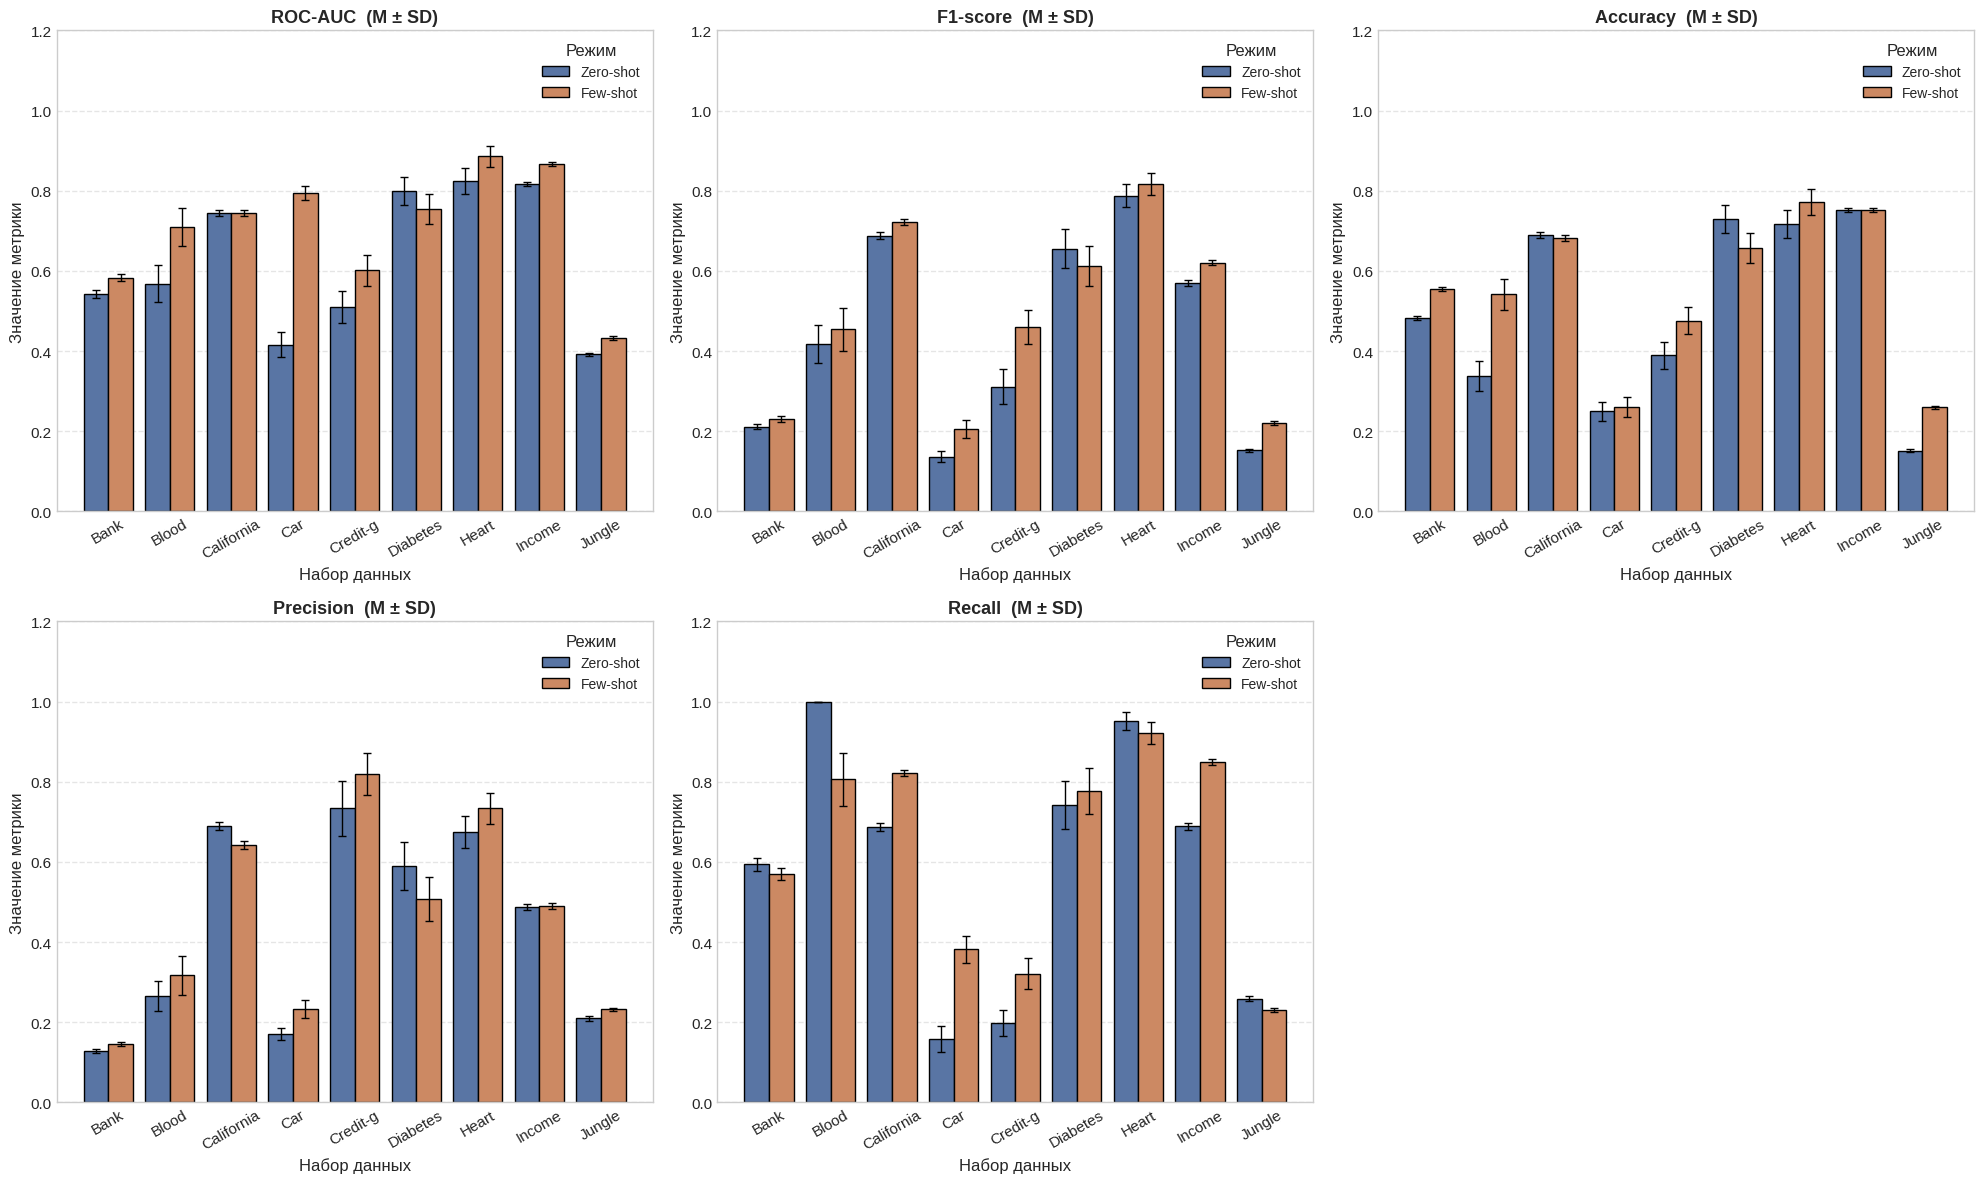

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.container import BarContainer

data = {
    'Dataset': ['Bank', 'Bank', 'Blood', 'Blood', 'California', 'California', 'Car', 'Car',
                'Credit-g', 'Credit-g', 'Diabetes', 'Diabetes', 'Heart', 'Heart', 'Income', 'Income', 'Jungle', 'Jungle'],
    'Mode': ['Zero-shot', 'Few-shot', 'Zero-shot', 'Few-shot', 'Zero-shot', 'Few-shot', 'Zero-shot', 'Few-shot',
             'Zero-shot', 'Few-shot', 'Zero-shot', 'Few-shot', 'Zero-shot', 'Few-shot', 'Zero-shot', 'Few-shot', 'Zero-shot', 'Few-shot'],
    'ROC-AUC': [0.5425, 0.5827, 0.5677, 0.7099, 0.7435, 0.7443, 0.4161, 0.7947, 0.5094, 0.6017, 0.7989, 0.7544, 0.8245, 0.8856, 0.8160, 0.8666, 0.3922, 0.4331],
    'ROC-AUC_sd': [0.0105, 0.0086, 0.0458, 0.0478, 0.0075, 0.0076, 0.0320, 0.0179, 0.0404, 0.0390, 0.0357, 0.0378, 0.0322, 0.0260, 0.0046, 0.0039, 0.0037, 0.0043],
    'F1-score': [0.2115, 0.2312, 0.4173, 0.4538, 0.6880, 0.7211, 0.1368, 0.2067, 0.3111, 0.4599, 0.6554, 0.6124, 0.7879, 0.8164, 0.5706, 0.6207, 0.1524, 0.2208],
    'F1-score_sd': [0.0070, 0.0074, 0.0468, 0.0546, 0.0084, 0.0076, 0.0139, 0.0225, 0.0438, 0.0429, 0.0491, 0.0493, 0.0296, 0.0283, 0.0079, 0.0070, 0.0038, 0.0042],
    'Accuracy': [0.4816, 0.5559, 0.3378, 0.5411, 0.6892, 0.6826, 0.2493, 0.2605, 0.3892, 0.4756, 0.7284, 0.6576, 0.7174, 0.7713, 0.7522, 0.7516, 0.1510, 0.2595],
    'Accuracy_sd': [0.0052, 0.0050, 0.0377, 0.0396, 0.0072, 0.0073, 0.0234, 0.0239, 0.0337, 0.0339, 0.0351, 0.0380, 0.0345, 0.0319, 0.0043, 0.0044, 0.0038, 0.0046],
    'Precision': [0.1287, 0.1450, 0.2648, 0.3177, 0.6900, 0.6426, 0.1703, 0.2327, 0.7334, 0.8187, 0.5899, 0.5078, 0.6735, 0.7337, 0.4873, 0.4889, 0.2097, 0.2324],
    'Precision_sd': [0.0048, 0.0052, 0.0375, 0.0486, 0.0105, 0.0095, 0.0144, 0.0224, 0.0677, 0.0519, 0.0593, 0.0554, 0.0401, 0.0393, 0.0085, 0.0076, 0.0057, 0.0042],
    'Recall': [0.5936, 0.5701, 1.0000, 0.8057, 0.6861, 0.8214, 0.1589, 0.3816, 0.1983, 0.3210, 0.7421, 0.7769, 0.9511, 0.9218, 0.6885, 0.8500, 0.2589, 0.2294],
    'Recall_sd': [0.0151, 0.0149, 0.0000, 0.0659, 0.0101, 0.0084, 0.0319, 0.0327, 0.0329, 0.0384, 0.0598, 0.0569, 0.0218, 0.0274, 0.0097, 0.0075, 0.0063, 0.0050]
}

df = pd.DataFrame(data)

metrics_ru = {
    'ROC-AUC': 'ROC-AUC',
    'F1-score': 'F1-score',
    'Accuracy': 'Accuracy',
    'Precision': 'Precision',
    'Recall': 'Recall'
}
metrics_en = list(metrics_ru.keys())

modes = ['Zero-shot', 'Few-shot']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)
axes_flat = axes.flatten()

for i, metric in enumerate(metrics_en):
    ax = axes_flat[i]

    sns.barplot(
        data=df, x='Dataset', y=metric, hue='Mode',
        hue_order=modes, ax=ax, edgecolor='black'
    )

    bar_containers = [c for c in ax.containers if isinstance(c, BarContainer)]
    for j, container in enumerate(bar_containers):
        current_mode = modes[j]
        yerr = df[df['Mode'] == current_mode][f'{metric}_sd'].values
        x_pos = [bar.get_x() + bar.get_width() / 2 for bar in container]
        y_pos = [bar.get_height() for bar in container]
        ax.errorbar(x=x_pos, y=y_pos, yerr=yerr, fmt='none', c='black', capsize=3, elinewidth=1)

    ax.set_title(rf'{metrics_ru[metric]}  (M ± SD)', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.2)
    ax.set_ylabel('Значение метрики')
    ax.set_xlabel('Набор данных')
    ax.legend(title='Режим', loc='upper right', fontsize='small')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

axes_flat[5].set_visible(False)

plt.tight_layout()

file_name = 'bar_chart_metrics_comparison_zero_few.png'

plt.savefig(file_name, dpi=300, bbox_inches='tight')

try:
    from google.colab import files
    files.download(file_name)
except ImportError:
    pass

plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

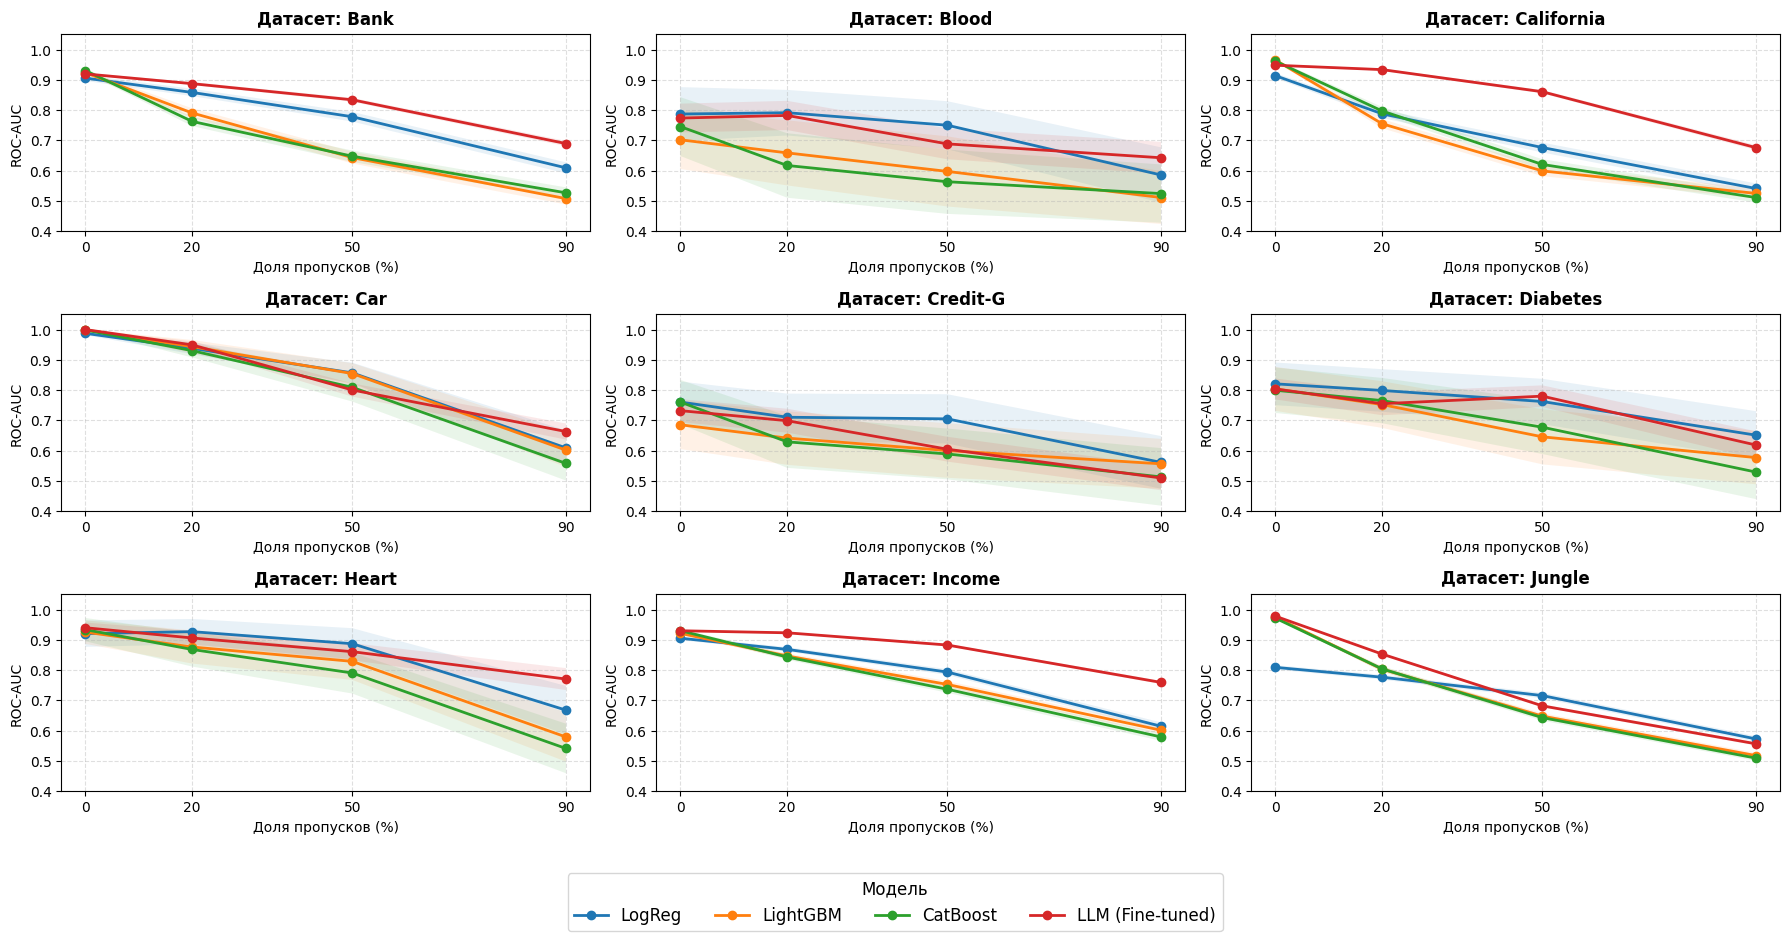

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

raw_data = {
    'Bank': {
        'LogReg': ['0.9057±0.0092', '0.8583±0.0122', '0.7779±0.0159', '0.6090±0.0182'],
        'CatBoost': ['0.9307±0.0066', '0.7625±0.0155', '0.6474±0.0189', '0.5264±0.0179'],
        'LightGBM': ['0.9238±0.0070', '0.7904±0.0156', '0.6428±0.0195', '0.5073±0.0194'],
        'LLM (Fine-tuned)': ['0.9196±0.0038', '0.8873±0.0051', '0.8339±0.0064', '0.6893±0.0087']
    },
    'Blood': {
        'LogReg': ['0.7869±0.0889', '0.7913±0.0753', '0.7499±0.0794', '0.5854±0.0914'],
        'CatBoost': ['0.7455±0.0972', '0.6168±0.1066', '0.5631±0.1063', '0.5239±0.0963'],
        'LightGBM': ['0.7017±0.0964', '0.6585±0.1076', '0.5972±0.1160', '0.5109±0.0876'],
        'LLM (Fine-tuned)': ['0.7736±0.0476', '0.7822±0.0483', '0.6882±0.0508', '0.6423±0.0526']
    },
    'California': {
        'LogReg': ['0.9138±0.0083', '0.7876±0.0136', '0.6761±0.0163', '0.5407±0.0168'],
        'CatBoost': ['0.9618±0.0051', '0.7970±0.0134', '0.6202±0.0173', '0.5108±0.0164'],
        'LightGBM': ['0.9656±0.0050', '0.7547±0.0149', '0.5988±0.0172', '0.5244±0.0166'],
        'LLM (Fine-tuned)': ['0.9482±0.0030', '0.9337±0.0035', '0.8606±0.0055', '0.6758±0.0082']
    },
    'Car': {
        'LogReg': ['0.9876±0.0059', '0.9379±0.0192', '0.8568±0.0338', '0.6087±0.0579'],
        'CatBoost': ['0.9985±0.0018', '0.9303±0.0223', '0.8090±0.0470', '0.5575±0.0566'],
        'LightGBM': ['0.9990±0.0019', '0.9434±0.0222', '0.8546±0.0344', '0.6014±0.0558'],
        'LLM (Fine-tuned)': ['1.0000±0.0000', '0.9494±0.0119', '0.8002±0.0218', '0.6629±0.0266']
    },
    'Credit-G': {
        'LogReg': ['0.7603±0.0678', '0.7102±0.0781', '0.7048±0.0814', '0.5609±0.0870'],
        'CatBoost': ['0.7605±0.0732', '0.6288±0.0860', '0.5888±0.0840', '0.5130±0.0951'],
        'LightGBM': ['0.6853±0.0804', '0.6412±0.0884', '0.6001±0.0901', '0.5561±0.0824'],
        'LLM (Fine-tuned)': ['0.7320±0.0380', '0.6987±0.0395', '0.6045±0.0410', '0.5093±0.0405']
    },
    'Diabetes': {
        'LogReg': ['0.8206±0.0705', '0.7987±0.0703', '0.7622±0.0750', '0.6509±0.0793'],
        'CatBoost': ['0.7994±0.0751', '0.7652±0.0749', '0.6772±0.0885', '0.5289±0.0894'],
        'LightGBM': ['0.8040±0.0726', '0.7520±0.0770', '0.6454±0.0911', '0.5768±0.0883'],
        'LLM (Fine-tuned)': ['0.8037±0.0346', '0.7549±0.0381', '0.7799±0.0357', '0.6183±0.0454']
    },
    'Heart': {
        'LogReg': ['0.9204±0.0437', '0.9270±0.0419', '0.8871±0.0513', '0.6675±0.0800'],
        'CatBoost': ['0.9337±0.0385', '0.8681±0.0565', '0.7903±0.0679', '0.5408±0.0819'],
        'LightGBM': ['0.9255±0.0390', '0.8763±0.0547', '0.8287±0.0612', '0.5788±0.0815'],
        'LLM (Fine-tuned)': ['0.9400±0.0172', '0.9061±0.0233', '0.8608±0.0283', '0.7703±0.0362']
    },
    'Income': {
        'LogReg': ['0.9053±0.0062', '0.8684±0.0074', '0.7934±0.0097', '0.6143±0.0127'],
        'CatBoost': ['0.9302±0.0053', '0.8432±0.0090', '0.7366±0.0115', '0.5789±0.0127'],
        'LightGBM': ['0.9214±0.0058', '0.8466±0.0089', '0.7525±0.0109', '0.6011±0.0120'],
        'LLM (Fine-tuned)': ['0.9300±0.0026', '0.9232±0.0028', '0.8828±0.0037', '0.7592±0.0053']
    },
    'Jungle': {
        'LogReg': ['0.8090±0.0071', '0.7764±0.0081', '0.7156±0.0092', '0.5723±0.0093'],
        'CatBoost': ['0.9717±0.0021', '0.8039±0.0088', '0.6428±0.0101', '0.5089±0.0092'],
        'LightGBM': ['0.9751±0.0020', '0.8030±0.0087', '0.6477±0.0097', '0.5173±0.0092'],
        'LLM (Fine-tuned)': ['0.9783±0.0009', '0.8528±0.0034', '0.6817±0.0049', '0.5562±0.0055']
    }
}

missing_ratios = [0, 20, 50, 90]
plot_data = []

for ds, models in raw_data.items():
    for model_name, values in models.items():
        for ratio, val_str in zip(missing_ratios, values):
            mean_val, sd_val = map(float, val_str.split('±'))
            plot_data.append({
                'Dataset': ds,
                'Missing_Ratio': ratio,
                'Model': model_name,
                'ROC_AUC_Mean': mean_val,
                'ROC_AUC_SD': sd_val
            })

df_plot = pd.DataFrame(plot_data)

datasets = sorted(df_plot['Dataset'].unique())
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 9))
plt.subplots_adjust(hspace=0.5, wspace=0.25)
axes_flat = axes.flatten()


for i, ds_name in enumerate(datasets):
    ax = axes_flat[i]
    subset = df_plot[df_plot['Dataset'] == ds_name]

    render_order = ['LogReg', 'LightGBM', 'CatBoost', 'LLM (Fine-tuned)']

    for model in render_order:
        model_data = subset[subset['Model'] == model]
        x = model_data['Missing_Ratio']
        y_mean = model_data['ROC_AUC_Mean']
        y_sd = model_data['ROC_AUC_SD']

        ax.plot(x, y_mean, marker='o',
                linewidth=2.0, markersize=6, label=model)

        ax.fill_between(x, y_mean - y_sd, y_mean + y_sd, alpha=0.1, linewidth=0)

    ax.set_title(f'Датасет: {ds_name}', fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Доля пропусков (%)', fontsize=10)
    ax.set_ylabel('ROC-AUC', fontsize=10)
    ax.set_xticks([0, 20, 50, 90])
    ax.set_ylim(0.40, 1.05)
    ax.grid(True, linestyle='--', alpha=0.4)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=12, title='Модель', title_fontsize=12, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.05, 1, 1])

file_name = 'missing_data_robustness_final.png'
plt.savefig(file_name, dpi=300, bbox_inches='tight')

try:
    from google.colab import files
    files.download(file_name)
except ImportError:
    pass

plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

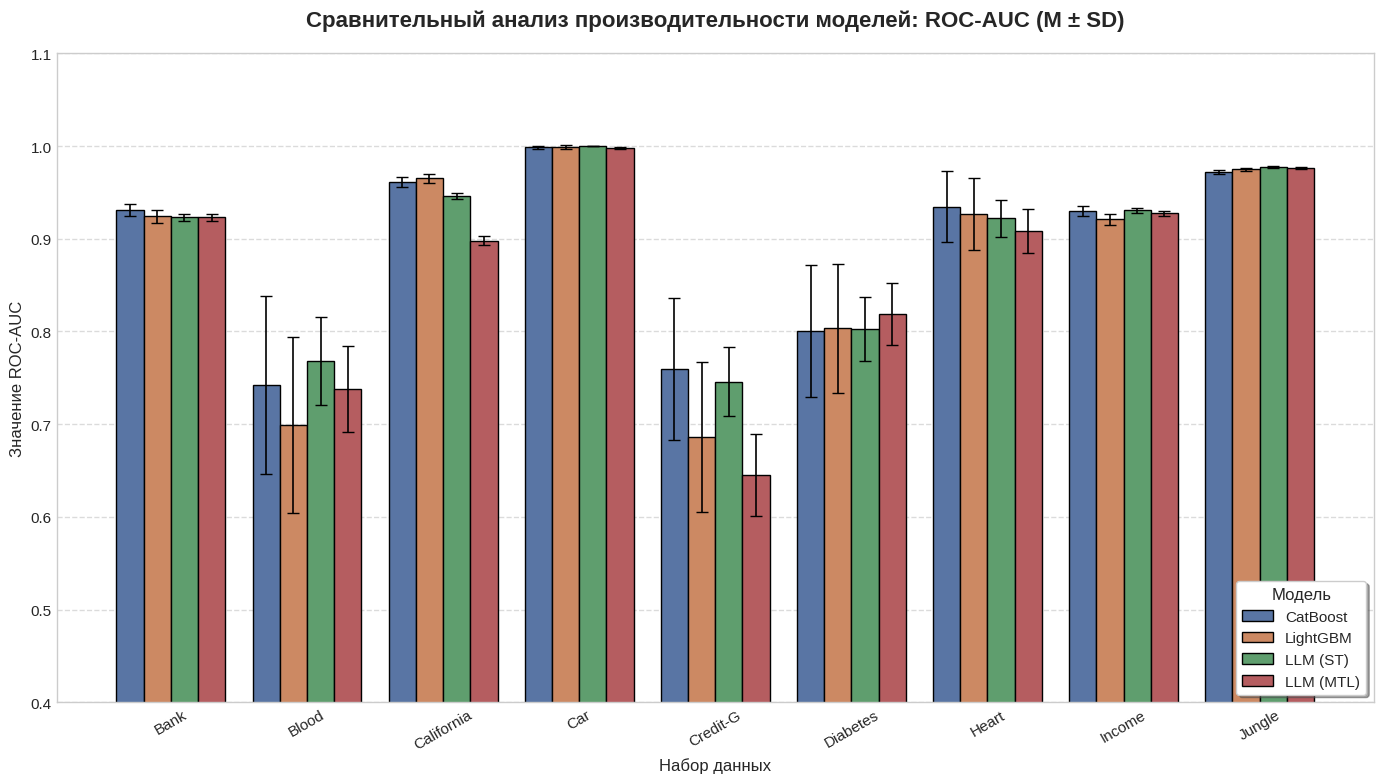

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.container import BarContainer

datasets = ['Bank', 'Blood', 'California', 'Car', 'Credit-G', 'Diabetes', 'Heart', 'Income', 'Jungle']
models = ['CatBoost', 'LightGBM', 'LLM (ST)', 'LLM (MTL)']

data = []

cat_roc = [0.9307, 0.7426, 0.9616, 0.9985, 0.7597, 0.8006, 0.9347, 0.9300, 0.9717]
cat_roc_sd = [0.0066, 0.0960, 0.0053, 0.0019, 0.0763, 0.0711, 0.0382, 0.0053, 0.0021]

lgb_roc = [0.9240, 0.6992, 0.9654, 0.9990, 0.6863, 0.8033, 0.9269, 0.9210, 0.9749]
lgb_roc_sd = [0.0070, 0.0953, 0.0049, 0.0019, 0.0812, 0.0698, 0.0389, 0.0057, 0.0019]

st_roc = [0.9232, 0.7683, 0.9457, 0.9998, 0.7457, 0.8027, 0.9220, 0.9306, 0.9774]
st_roc_sd = [0.0038, 0.0475, 0.0031, 0.0002, 0.0371, 0.0346, 0.0202, 0.0026, 0.0009]

mtl_roc = [0.9233, 0.7384, 0.8979, 0.9978, 0.6451, 0.8187, 0.9082, 0.9276, 0.9764]
mtl_roc_sd = [0.0038, 0.0464, 0.0046, 0.0011, 0.0443, 0.0332, 0.0238, 0.0027, 0.0009]

for i, ds in enumerate(datasets):
    roc_vals = [cat_roc[i], lgb_roc[i], st_roc[i], mtl_roc[i]]
    sd_vals = [cat_roc_sd[i], lgb_roc_sd[i], st_roc_sd[i], mtl_roc_sd[i]]
    for j, model in enumerate(models):
        data.append({
            'Dataset': ds,
            'Model': model,
            'ROC-AUC': roc_vals[j],
            'ROC-AUC_sd': sd_vals[j]
        })

df = pd.DataFrame(data)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))

sns.barplot(
    data=df, x='Dataset', y='ROC-AUC', hue='Model',
    hue_order=models, ax=ax, edgecolor='black'
)

bar_containers = [c for c in ax.containers if isinstance(c, BarContainer)]
for j, container in enumerate(bar_containers):
    current_model = models[j]
    yerr = df[df['Model'] == current_model]['ROC-AUC_sd'].values
    x_pos = [bar.get_x() + bar.get_width() / 2 for bar in container]
    y_pos = [bar.get_height() for bar in container]
    ax.errorbar(x=x_pos, y=y_pos, yerr=yerr, fmt='none', c='black', capsize=4, elinewidth=1.2)

ax.set_title('Сравнительный анализ производительности моделей: ROC-AUC (M ± SD)', fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0.4, 1.1)
ax.set_ylabel('Значение ROC-AUC', fontsize=12)
ax.set_xlabel('Набор данных', fontsize=12)
ax.legend(title='Модель', loc='lower right', frameon=True, shadow=True)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
file_name = 'roc_auc_comparison_final.png'
plt.savefig(file_name, dpi=300, bbox_inches='tight')

try:
    from google.colab import files
    files.download(file_name)
except ImportError:
    pass

plt.show()